In [3]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Create employee dataset
n_employees = 1000

df = pd.DataFrame({
    'employee_id': range(1, n_employees + 1),
    'name': [f'Employee_{i}' for i in range(1, n_employees + 1)],
    'department': np.random.choice(['Sales', 'IT', 'HR', 'Marketing', 'Finance'], n_employees),
    'salary': np.random.normal(50000, 15000, n_employees),
    'years_experience': np.random.randint(0, 40, n_employees),
    'age': np.random.randint(22, 65, n_employees),
    'performance_score': np.random.uniform(1, 5, n_employees),
    'join_date': pd.date_range('2015-01-01', '2024-12-31', periods=n_employees),
    'bonus': np.random.choice([np.nan, 1000, 2000, 3000, 5000], n_employees, p=[0.3, 0.3, 0.2, 0.15, 0.05]),
    'remote': np.random.choice([True, False], n_employees),
    'projects_completed': np.random.poisson(5, n_employees)
})

# Introduce some missing values
df.loc[np.random.choice(n_employees, 50), 'performance_score'] = np.nan
df.loc[np.random.choice(n_employees, 30), 'salary'] = np.nan

print("Dataset created!")
print(f"Shape: {df.shape}")
print(df.head(10))

Dataset created!
Shape: (1000, 11)
   employee_id         name department        salary  years_experience  age  \
0            1   Employee_1  Marketing  51640.921919                 5   24   
1            2   Employee_2    Finance  60886.499358                38   45   
2            3   Employee_3         HR  57215.138476                22   48   
3            4   Employee_4    Finance  53358.260364                24   61   
4            5   Employee_5    Finance  38142.883168                18   57   
5            6   Employee_6         IT  57072.025357                 4   55   
6            7   Employee_7         HR  78230.367447                10   50   
7            8   Employee_8         HR  70181.300692                11   45   
8            9   Employee_9         HR  73897.799400                 9   45   
9           10  Employee_10    Finance  42331.764854                 7   63   

   performance_score                     join_date   bonus  remote  \
0           3.460517 2015

In [4]:
df.describe()

,employee_id,salary,years_experience,age,performance_score,join_date,bonus,projects_completed
count,1000.000000,970.000000,1000.000000,1000.000000,952.000000,1000,701.000000,1000.000000
mean,500.500000,51047.953269,19.802000,43.024000,2.966219,2020-01-01 00:00:00,1991.440799,4.931000
min,1.000000,6179.742748,0.000000,22.000000,1.000123,2015-01-01 00:00:00,1000.000000,0.000000
25%,250.750000,40834.753958,10.000000,33.000000,1.992476,2017-07-02 00:00:00,1000.000000,3.000000
50%,500.500000,50852.472873,20.000000,43.000000,2.955644,2020-01-01 00:00:00,2000.000000,5.000000
75%,750.250000,60632.628950,29.000000,53.000000,3.925956,2022-07-02 00:00:00,3000.000000,6.000000
max,1000.000000,97896.613518,39.000000,64.000000,4.990998,2024-12-31 00:00:00,5000.000000,14.000000
std,288.819436,15138.704148,11.485936,12.261067,1.144482,NaN,1179.557208,2.143089


/tmp/ipykernel_80937/2806461095.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='department', order=df['department'].value_counts().index, palette='viridis')
/tmp/ipykernel_80937/2806461095.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='department', y='salary', palette='pastel')


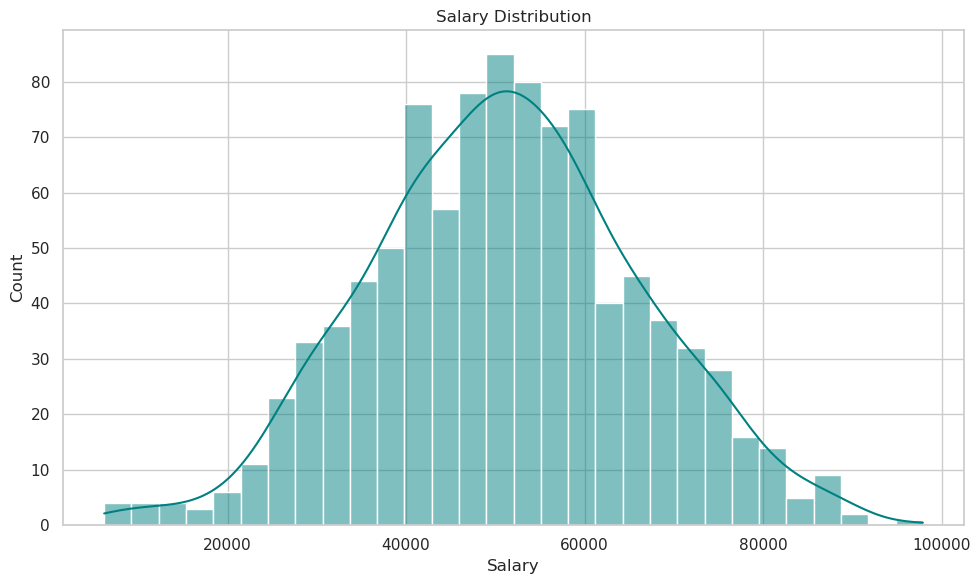

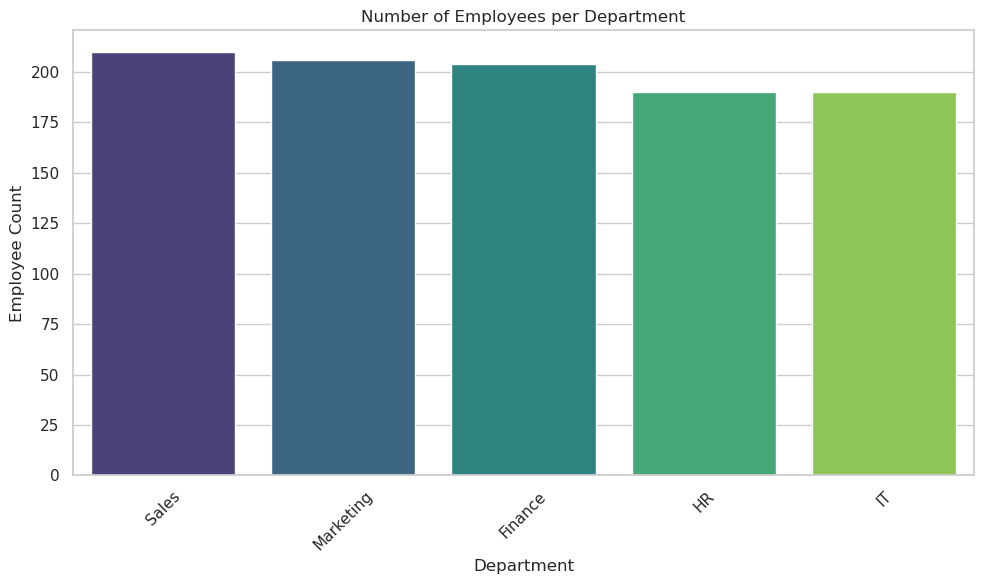

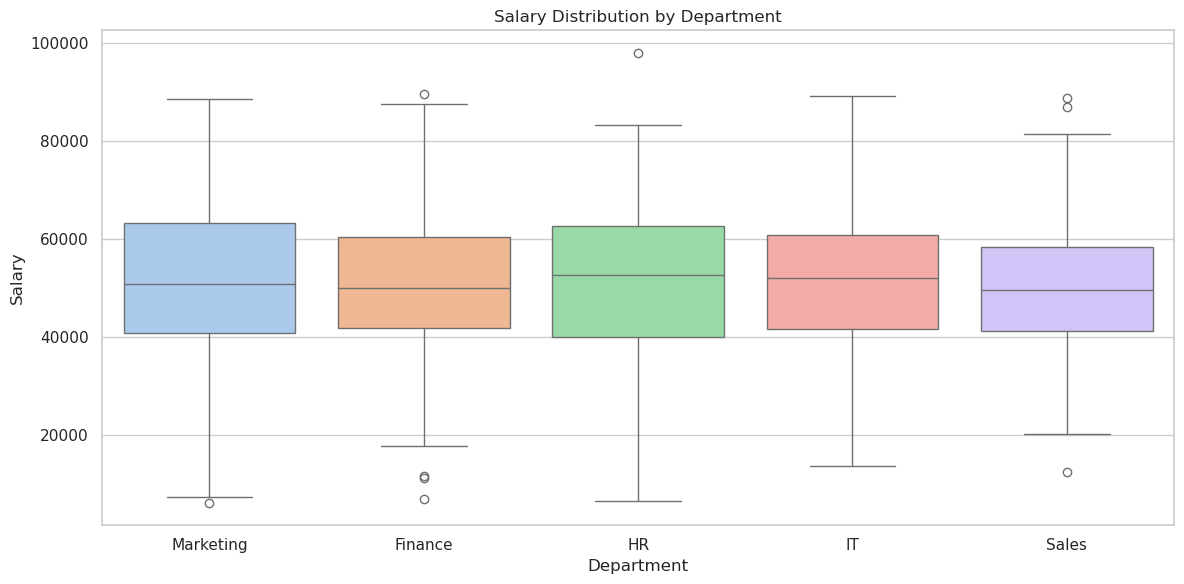

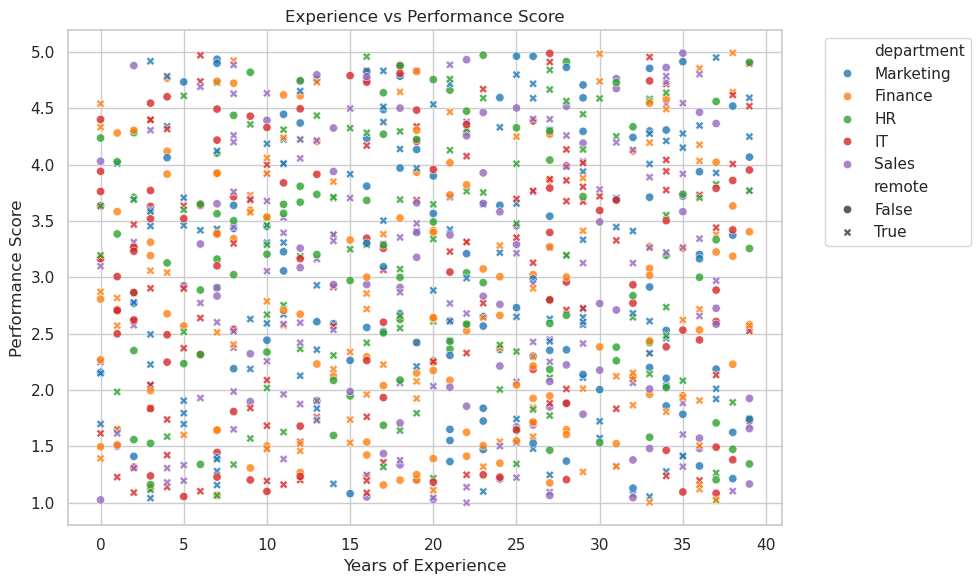

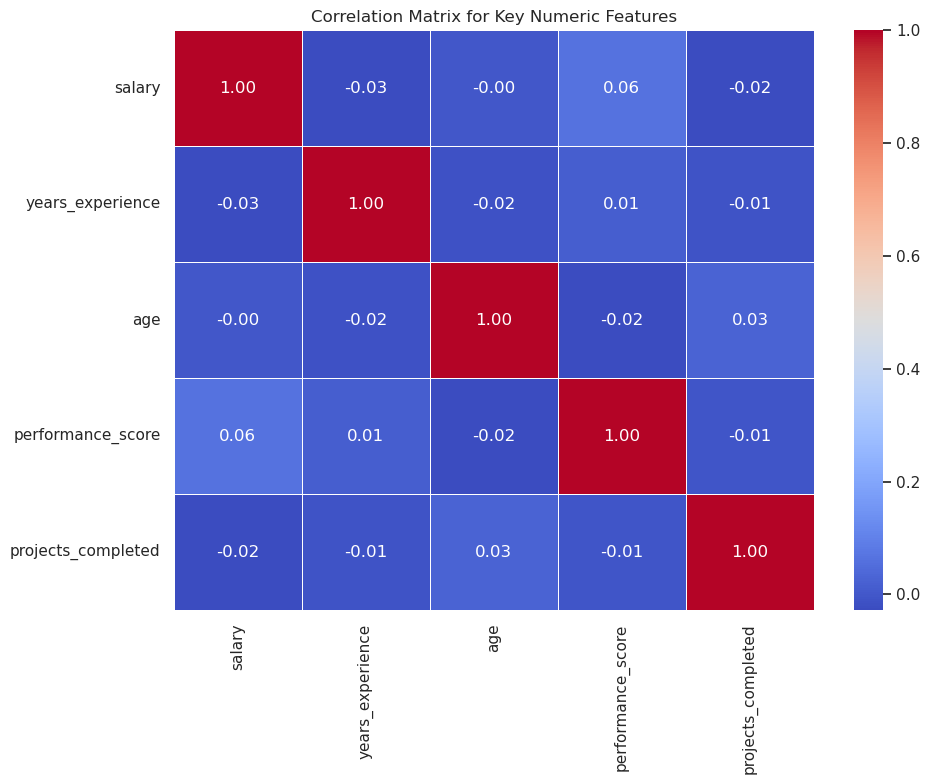

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Distribution of salaries
plt.figure(figsize=(10, 6))
sns.histplot(df['salary'].dropna(), kde=True, bins=30, color='teal')
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Count')
plt.tight_layout()

# Employees per department
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='department', order=df['department'].value_counts().index, palette='viridis')
plt.title('Number of Employees per Department')
plt.xlabel('Department')
plt.ylabel('Employee Count')
plt.xticks(rotation=45)
plt.tight_layout()

# Salary by department
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='department', y='salary', palette='pastel')
plt.title('Salary Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Salary')
plt.tight_layout()

# Relationship between experience and performance
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.dropna(subset=['performance_score']),
    x='years_experience',
    y='performance_score',
    hue='department',
    style='remote',
    palette='tab10',
    alpha=0.8
)
plt.title('Experience vs Performance Score')
plt.xlabel('Years of Experience')
plt.ylabel('Performance Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_columns = ['salary', 'years_experience', 'age', 'performance_score', 'projects_completed']
_corr = df[correlation_columns].corr()
sns.heatmap(_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix for Key Numeric Features')
plt.tight_layout()


In [6]:
df.isnull()

,employee_id,name,department,salary,years_experience,age,performance_score,join_date,bonus,remote,projects_completed
0,False,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,False
996,False,False,False,True,False,False,False,False,True,False,False
997,False,False,False,False,False,False,True,False,True,False,False
998,False,False,False,False,False,False,False,False,False,False,False


In [7]:
deph_count = df['department'].value_counts()
deph_count

department
Sales        210
Marketing    206
Finance      204
HR           190
IT           190
Name: count, dtype: int64

In [8]:
df[df['salary'] > 70000]

,employee_id,name,department,salary,years_experience,age,performance_score,join_date,bonus,remote,projects_completed
6,7,Employee_7,HR,78230.367447,10,50,3.204640,2015-01-22 22:24:51.891891891,3000.0,False,4
7,8,Employee_8,HR,70181.300692,11,45,2.752714,2015-01-26 14:09:00.540540540,2000.0,True,8
8,9,Employee_9,HR,73897.799400,9,45,4.356722,2015-01-30 05:53:09.189189189,NaN,True,5
15,16,Employee_16,IT,72943.254792,7,26,1.446372,2015-02-24 20:02:09.729729729,NaN,False,7
25,26,Employee_26,HR,75035.322879,15,42,1.947733,2015-04-02 09:23:36.216216216,NaN,False,7
...,...,...,...,...,...,...,...,...,...,...,...
942,943,Employee_943,HR,72390.328534,19,53,1.794526,2024-06-05 15:03:47.027027008,NaN,True,2
981,982,Employee_982,Marketing,80862.432046,39,37,4.247785,2024-10-26 04:45:24.324324288,NaN,True,5
985,986,Employee_986,HR,70623.146287,3,51,1.526748,2024-11-09 19:41:58.918918912,1000.0,False,3
991,992,Employee_992,HR,74370.176877,18,39,NaN,2024-12-01 18:06:50.810810816,1000.0,False,7


In [9]:
avg_dep = df.groupby('department')['salary'].sum()
avg_dep

department
Finance      1.009376e+07
HR           9.569043e+06
IT           9.469474e+06
Marketing    1.039413e+07
Sales        9.990105e+06
Name: salary, dtype: float64

In [10]:
df[(df['years_experience'] > 10) & (df['performance_score'] > 4.0)]

,employee_id,name,department,salary,years_experience,age,performance_score,join_date,bonus,remote,projects_completed
1,2,Employee_2,Finance,60886.499358,38,45,4.642423,2015-01-04 15:44:08.648648648,2000.0,True,4
20,21,Employee_21,IT,NaN,19,31,4.205783,2015-03-15 02:42:52.972972972,2000.0,False,6
22,23,Employee_23,Marketing,30650.586504,11,28,4.003079,2015-03-22 10:11:10.270270270,NaN,True,6
28,29,Employee_29,Marketing,46313.854039,26,43,4.716579,2015-04-13 08:36:02.162162162,NaN,True,4
32,33,Employee_33,Marketing,46535.982047,27,59,4.307434,2015-04-27 23:32:36.756756756,1000.0,True,3
...,...,...,...,...,...,...,...,...,...,...,...
977,978,Employee_978,IT,63559.022616,18,60,4.809547,2024-10-11 13:48:49.729729728,NaN,False,7
980,981,Employee_981,HR,59287.313915,25,46,4.007301,2024-10-22 13:01:15.675675648,NaN,True,5
981,982,Employee_982,Marketing,80862.432046,39,37,4.247785,2024-10-26 04:45:24.324324288,NaN,True,5
984,985,Employee_985,HR,47256.553383,13,38,4.434026,2024-11-06 03:57:50.270270272,1000.0,True,4
